# Baseline Models
- Claim: With the current data, the model will fail to extrapolate, and may also fail to interpolate. 

- Target Selection & Justification: mu is the target since in EC NDT for ferromagnetic materials, primary characterisation is by permeability so it takes priority. Also, it is linearly spaced on a non linear problem which is a structural mismatch. 

- Data Request: If the model is successful in interpolation but fails at extrapolation, then request a wider range of mu and if both fail , request denser and wider mu values.

- Interpolation Test: LOGO CV excluding edges, 9 folds, tree-based model, pooled predictions.

- Extrapolation Test: Nested LOGO CV on edges only, polynomial regression + Standardisation + Elastic Net, per-edge reporting

- Model Selection(For polynomial regression): GridSearchCV,  R2

- Evaluation Metrics & Thresholds: MAPE (primary, threshold 10%, motivated from Xia et al. proportional reduction) and RMSE 

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.data import load_data
from src.features import run_logo_interpolation, plot_response_vs_permeability, plot_response_step_vs_resistivity, round_sig, compute_phase
from IPython.display import display
from sklearn.model_selection import GroupKFold, LeaveOneGroupOut, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge, RidgeCV

ModuleNotFoundError: No module named 'src'

In [ ]:
RANDOM_STATE = 42

In [ ]:
df = load_data('test.xlsx')

In [ ]:
df.head(5)

,permeability,resistivity,H_imag_375,H_imag_750,H_imag_1500,H_imag_3000,H_imag_6000,H_imag_12000,H_imag_24000,H_imag_48000,H_real_375,H_real_750,H_real_1500,H_real_3000,H_real_6000,H_real_12000,H_real_24000,H_real_48000
0,50,2.000000e-07,-0.000097,-0.000178,-0.000228,-0.000175,-0.000091,-0.000041,-0.000023,-0.000011,0.000079,1.832591e-05,-0.000122,-0.000263,-0.000318,-0.000324,-0.000325,-0.000333
1,50,4.000000e-07,-0.000098,-0.000177,-0.000226,-0.000172,-0.000088,-0.000040,-0.000022,-0.000009,0.000069,9.733506e-06,-0.000129,-0.000269,-0.000322,-0.000328,-0.000328,-0.000336
2,50,6.000000e-07,-0.000101,-0.000176,-0.000225,-0.000171,-0.000087,-0.000038,-0.000021,-0.000008,0.000063,3.736263e-06,-0.000134,-0.000272,-0.000325,-0.000330,-0.000330,-0.000337
3,50,8.000000e-07,-0.000103,-0.000177,-0.000224,-0.000170,-0.000086,-0.000038,-0.000020,-0.000008,0.000060,-7.607449e-07,-0.000137,-0.000275,-0.000328,-0.000332,-0.000332,-0.000339
4,50,1.000000e-06,-0.000105,-0.000178,-0.000223,-0.000170,-0.000086,-0.000037,-0.000019,-0.000007,0.000059,-4.063072e-06,-0.000141,-0.000277,-0.000330,-0.000334,-0.000333,-0.000340


In [ ]:
df.shape

(55, 18)

## Permeability

#### Interpolation

In [ ]:
# RF interpolation
rf = RandomForestRegressor(n_estimators=500, 
    min_samples_leaf=1,
    random_state=RANDOM_STATE,
    n_jobs=-1)

X = df.iloc[:, 2:]
y = df['permeability']
groups = np.asarray(df['permeability'].values)
rf_interpolation_results, rf_pooled_mape, rf_pooled_rmse = run_logo_interpolation(rf, X, y, groups, 'permeability')

print(f"Pooled Interpolation Performance (RF Regression)")
print(f"Pooled MAPE: {rf_pooled_mape}%")
print(f"Pooled RMSE: {rf_pooled_rmse}")

print(f"\nPer-Fold Diagnostics (RF Regression)")
display(rf_interpolation_results[['held_out_permeability', 'fold_mape', 'fold_rmse']])

# Example: Average Feature Importances across folds
avg_importances = pd.DataFrame(rf_interpolation_results['feature_importances'].tolist()).mean()
print(f"\nAVERAGE FEATURE IMPORTANCES")
display(avg_importances.sort_values(ascending=False))

Pooled Interpolation Performance (RF Regression)
Pooled MAPE: 28.0%
Pooled RMSE: 89.6

Per-Fold Diagnostics (RF Regression)


,held_out_permeability,fold_mape,fold_rmse
0,100,92.98,104.0
1,200,50.93,103.0
2,300,34.10,111.0
3,400,24.10,107.0
4,500,12.98,70.9
5,600,12.91,82.5
6,700,14.01,102.0
7,800,6.06,56.1
8,900,3.93,40.9



AVERAGE FEATURE IMPORTANCES


H_imag_48000    0.913532
H_imag_24000    0.047352
H_real_24000    0.006117
H_real_12000    0.003593
H_imag_750      0.003468
H_real_375      0.003079
H_real_48000    0.002995
H_imag_12000    0.002592
H_real_1500     0.002536
H_imag_1500     0.002467
H_real_750      0.002340
H_real_6000     0.002325
H_real_3000     0.002249
H_imag_6000     0.001982
H_imag_375      0.001860
H_imag_3000     0.001513
dtype: float64

In [ ]:
lin_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('linreg', LinearRegression())
])

X = df.iloc[:, 2:]
y = df['permeability']
groups = np.asarray(df['permeability'].values)

lr_interpolation_results, lr_pooled_mape, lr_pooled_rmse = run_logo_interpolation(lin_pipe, X, y, groups, 'permeability')

print(f"Pooled Interpolation Performance (LR Regression)")
print(f"Pooled MAPE: {lr_pooled_mape}%")
print(f"Pooled RMSE: {lr_pooled_rmse}")

print(f"\nPer-Fold Diagnostics (LR Regression)")
display(lr_interpolation_results[['held_out_permeability', 'fold_mape', 'fold_rmse']])


Pooled Interpolation Performance (LR Regression)
Pooled MAPE: 9.17%
Pooled RMSE: 25.6

Per-Fold Diagnostics (LR Regression)


,held_out_permeability,fold_mape,fold_rmse
0,100,50.35,55.6
1,200,12.46,27.5
2,300,6.44,20.1
3,400,3.32,16.0
4,500,1.92,13.3
5,600,2.26,14.6
6,700,2.41,18.2
7,800,1.75,18.3
8,900,1.66,17.8


#### Extrapolation

In [ ]:
# Extrapolation of permeability using Polynomial Regression
# Consider only edge targets results for true extrapolation
X = df.iloc[:, 2:]
y = df['permeability']
groups = np.asarray(df['permeability'].values)
edge_groups = set(np.unique(groups)[[0, -1]])
extra_results = []

# Define the Pipeline
pipe = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('elastic_net', ElasticNet(max_iter=50000, tol=1e-3, random_state=RANDOM_STATE))
])

#Define the parameter grid for hypertuning
param_grid = {
    'poly__degree':[1, 2, 3],
    'elastic_net__alpha':[0.1, 1, 10, 100],
    'elastic_net__l1_ratio':[0.1, 0.3, 0.5, 0.7, 0.9]
}

# Outer Splitter (11 Folds, train=50, test=5)
outer_cv = LeaveOneGroupOut()

# Inner Splitter (5 splits, train=40, test=10)
inner_cv = GroupKFold(n_splits=5)

gridsearch = GridSearchCV(
    estimator = pipe,
    param_grid = param_grid,
    scoring = '',
    cv = inner_cv,
    n_jobs = -1,
    error_score = 'raise',
    verbose = 2,
)

''' 
Manual cross_val_score for nested cross-validation

Outer Loop: Model Evaluation -> 
Tests the model on unseen data(Held out Group)
Inner Loop (Inside GridSearchCV): Finds best model to be used for eval 
by Hyperparameter Tuning (best degree/alpha/l1_ratio)
'''
for outer_train_ids, outer_test_ids in outer_cv.split(X, y, groups):

    # Identify the held out permeability value for each fold
    held_out = np.unique(groups[outer_test_ids])[0]
    if held_out not in edge_groups:
        continue
    # Extract data for inner split
    X_outer_train = X.iloc[outer_train_ids]
    y_outer_train = y.iloc[outer_train_ids]
    groups_outer_train = groups[outer_train_ids]
    X_outer_test = X.iloc[outer_test_ids]
    y_outer_test = y.iloc[outer_test_ids]
  
    # Fit GridSearchCV on outer split train data
    # GridSearchCV internally performs the 5-fold GroupKFold
    gridsearch.fit(X_outer_train, y_outer_train, groups=groups_outer_train)

    # Predict on Outer split Test Data (Held-Out Fold)
    extra_pred = gridsearch.predict(X_outer_test)

    # Extract results

    # 1. Per-Edge Metrics(MAPE, RMSE)
    mape = mean_absolute_percentage_error(y_outer_test, extra_pred)*100
    rmse = root_mean_squared_error(y_outer_test, extra_pred)

    # 2. Seleted Hyperparameters
    best_params = gridsearch.best_params_

    # 3. Inner CV Performance ( R2 of the best model on inner folds)
    inner_best_score = gridsearch.best_score_

    # 4. Coefficents of the Fitted Polynomial
    best_model = gridsearch.best_estimator_
    elastic_net_step = best_model.named_steps['elastic_net']
    coefficients = elastic_net_step.coef_
    intercept = elastic_net_step.intercept_

    #5. Feature Names for coefficients to interpret the polynomial function
    poly_step = best_model.named_steps['poly']
    feature_names = poly_step.get_feature_names_out(X.columns)

    # Create a dictionary mapping features to coefficients
    coef_dict = dict(zip(feature_names, coefficients))

    # Store all results
    extra_results.append({
        'target': 'permeability',
        'held_out_target': held_out,
        'true_values': [round_sig(v) for v in y_outer_test],
        'predicted_values': [round_sig(v) for v in extra_pred],
        'MAPE': round(mape, 2),
        'RMSE': round_sig(rmse),
        'best_degree': best_params['poly__degree'],
        'best_alpha': best_params['elastic_net__alpha'],
        'best_l1_ratio':best_params['elastic_net__l1_ratio'],
        'inner_cv_r2': round_sig(inner_best_score, 2),
        'intercept': round_sig(intercept),
        'coefficients': {k: round_sig(v) for k,v in coef_dict.items()}
        })

p_extrapolation_results = pd.DataFrame(extra_results)   

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Fitting 5 folds for each of 60 candidates, totalling 300 fits


In [ ]:
# Display Results
print("Per_Edge Performance")
display(p_extrapolation_results[['held_out_target', 'MAPE', 'RMSE']])
print("\nSelected Hyperparameters")
display(p_extrapolation_results[['held_out_target', 'best_degree', 'best_alpha', 'best_l1_ratio']])
print("\nTrue vs Reality")
display(p_extrapolation_results[['held_out_target', 'true_values', 'predicted_values', 'inner_cv_r2', 'MAPE']])

print("\n=== Coefficients for Held-Out Group 50 (Example) ===")

# Access the specific row for group 50 
edge_case1 = p_extrapolation_results[p_extrapolation_results['held_out_target'] == 50].iloc[0]
print(f"Intercept: {edge_case1['intercept']}")
# Sort coefficients by magnitude to see dominant terms
sorted_coefs = sorted(edge_case1['coefficients'].items(), key=lambda x: abs(x[1]), reverse=True)
for term, val in sorted_coefs[:10]: # Print top 10
    print(f"{term}: {val:.4f}")
    
# print("\n=== Coefficients for Held-Out Group 1000 (Example) ===")

# # Access the specific row for group 1000 
# edge_case2 = p_extrapolation_results[p_extrapolation_results['held_out_target'] == 1000].iloc[0]
# print(f"Intercept: {edge_case2['intercept']}")
# # Sort coefficients by magnitude to see dominant terms
# sorted_coefs = sorted(edge_case2['coefficients'].items(), key=lambda x: abs(x[1]), reverse=True)
# for term, val in sorted_coefs[:10]: # Print top 10
#     print(f"{term}: {val:.4f}")

Per_Edge Performance


,held_out_target,MAPE,RMSE
0,50,34.56,28.5
1,1000,7.07,79.3



Selected Hyperparameters


,held_out_target,best_degree,best_alpha,best_l1_ratio
0,50,3,1,0.9
1,1000,3,1,0.7



True vs Reality


,held_out_target,true_values,predicted_values,inner_cv_r2,MAPE
0,50,"[50.0, 50.0, 50.0, 50.0, 50.0]","[-12.2, 54.6, 54.6, 53.5, 61.5]",0.98,34.56
1,1000,"[1000.0, 1000.0, 1000.0, 1000.0, 1000.0]","[921.0, 1050.0, 984.0, 920.0, 875.0]",0.98,7.07



=== Coefficients for Held-Out Group 50 (Example) ===
Intercept: 550.0
H_imag_48000 H_real_750^2: 34.6000
H_real_375 H_real_1500^2: 12.4000
H_imag_48000^2 H_real_750: -7.3300
H_imag_1500 H_imag_3000^2: -7.2200
H_imag_6000^2 H_real_12000: -6.9400
H_imag_3000^2: 6.2000
H_imag_6000^2 H_real_6000: -6.1900
H_imag_3000: -6.1200
H_imag_1500 H_imag_3000 H_imag_6000: -5.6400
H_imag_1500^2 H_imag_6000: -5.5100


### Response vs Permeability

--- Step Size (ρ = 2e-07) ---


,H_real_375,H_real_750,H_real_1500,H_real_3000,H_real_6000,H_real_12000,H_real_24000,H_real_48000
permeability,,,,,,,,
50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100,-8.464,-8.629,-7.591,-5.916,-4.565,-3.792,-3.195,-2.472
200,-8.047,-8.609,-8.211,-6.784,-5.470,-4.764,-4.210,-3.095
300,-4.246,-4.838,-4.880,-4.235,-3.574,-3.267,-2.917,-1.882
400,-2.791,-3.273,-3.414,-3.066,-2.680,-2.522,-2.195,-1.241
500,-2.034,-2.427,-2.591,-2.391,-2.150,-2.048,-1.728,-0.845
600,-1.574,-1.903,-2.068,-1.952,-1.796,-1.713,-1.403,-0.580
700,-1.267,-1.550,-1.707,-1.645,-1.540,-1.462,-1.163,-0.397
800,-1.051,-1.296,-1.446,-1.418,-1.344,-1.268,-0.980,-0.269


--- Step Size (ρ = 4e-07) ---


,H_real_375,H_real_750,H_real_1500,H_real_3000,H_real_6000,H_real_12000,H_real_24000,H_real_48000
permeability,,,,,,,,
50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100,-6.733,-8.570,-8.314,-6.815,-5.479,-4.712,-4.081,-3.258
200,-6.501,-8.169,-8.342,-7.345,-6.203,-5.582,-5.110,-4.293
300,-3.552,-4.331,-4.709,-4.355,-3.832,-3.609,-3.494,-2.966
400,-2.293,-2.858,-3.196,-3.043,-2.756,-2.688,-2.694,-2.225
500,-1.636,-2.089,-2.375,-2.308,-2.139,-2.146,-2.187,-1.746
600,-1.252,-1.619,-1.866,-1.841,-1.740,-1.787,-1.829,-1.414
700,-1.003,-1.306,-1.521,-1.520,-1.462,-1.528,-1.561,-1.170
800,-0.830,-1.084,-1.274,-1.288,-1.257,-1.332,-1.354,-0.982


--- Step Size (ρ = 6e-07) ---


...

--- Step Size (ρ = 8e-07) ---


,H_real_375,H_real_750,H_real_1500,H_real_3000,H_real_6000,H_real_12000,H_real_24000,H_real_48000
permeability,,,,,,,,
50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100,-6.341,-6.868,-8.321,-7.447,-6.225,-5.585,-5.051,-4.168
200,-4.894,-6.667,-7.960,-7.453,-6.618,-6.237,-5.958,-5.227
300,-2.480,-3.647,-4.250,-4.198,-3.881,-3.809,-3.837,-3.575
400,-1.684,-2.359,-2.818,-2.846,-2.694,-2.719,-2.849,-2.754
500,-1.247,-1.689,-2.065,-2.114,-2.034,-2.098,-2.271,-2.233
600,-0.962,-1.295,-1.604,-1.660,-1.617,-1.699,-1.888,-1.865
700,-0.765,-1.040,-1.296,-1.353,-1.331,-1.422,-1.613,-1.590
800,-0.626,-0.862,-1.078,-1.133,-1.125,-1.219,-1.405,-1.377


--- Step Size (ρ = 1e-06) ---


,H_real_375,H_real_750,H_real_1500,H_real_3000,H_real_6000,H_real_12000,H_real_24000,H_real_48000
permeability,,,,,,,,
50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100,-6.557,-6.480,-7.906,-7.587,-6.403,-5.831,-5.359,-4.485
200,-4.845,-5.977,-7.674,-7.387,-6.666,-6.382,-6.201,-5.517
300,-2.236,-3.330,-4.064,-4.094,-3.843,-3.831,-3.918,-3.706
400,-1.470,-2.192,-2.665,-2.753,-2.641,-2.701,-2.867,-2.832
500,-1.098,-1.568,-1.947,-2.032,-1.980,-2.064,-2.259,-2.295
600,-0.861,-1.195,-1.511,-1.589,-1.564,-1.658,-1.862,-1.923
700,-0.693,-0.954,-1.220,-1.291,-1.282,-1.378,-1.581,-1.645
800,-0.570,-0.788,-1.013,-1.079,-1.078,-1.174,-1.372,-1.430


(<Figure size 700x500 with 1 Axes>,
 <Axes: title={'center': 'H_real vs Permeability (averaged over resistivity)'}, xlabel='Permeability (μᵣ)', ylabel='H_real (μH)'>)

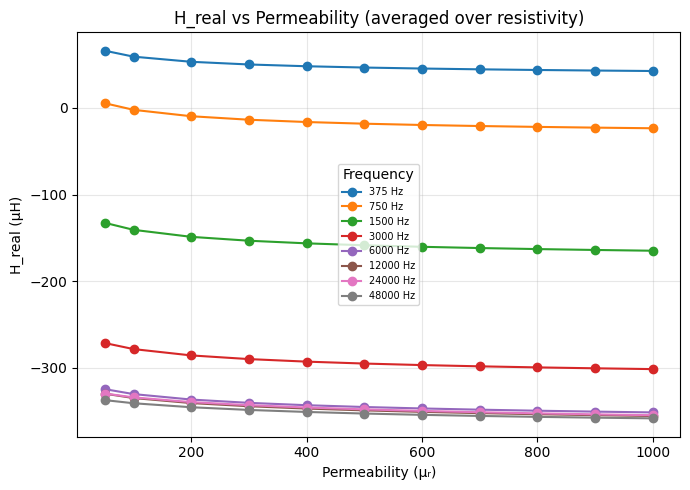

In [ ]:
# Response vs Permeability
# step-to-step change as resistivity permebility increases
real_cols = ['H_real_375','H_real_750','H_real_1500', 'H_real_3000', 'H_real_6000', 'H_real_12000', 'H_real_24000', 'H_real_48000']

for r in sorted(df['resistivity'].unique()):
    p_sub_real = df[df['resistivity'] == r].sort_values('permeability').set_index('permeability')
    # print(f'=== ρ = {r} (H_real, μH) ===')
    # display(round(p_sub_real[real_cols] *1e6, 3))
    print(f'--- Step Size (ρ = {r}) ---')
    display(round(p_sub_real[real_cols].diff() *1e6, 3))

plot_response_vs_permeability(df, component='real')

In [ ]:
imag_cols= [ 'H_imag_375','H_imag_750','H_imag_1500', 'H_imag_3000', 'H_imag_6000', 'H_imag_12000', 'H_imag_24000', 'H_imag_48000']

for r in sorted(df['resistivity'].unique()):
    p_sub_imag = df[df['resistivity'] == r].sort_values('permeability').set_index('permeability')
    # print(f'=== ρ = {r} (H_imag, μH) ===')
    # display(round(p_sub_imag[imag_cols] *1e6, 3))
    print(f'--- Step Size (ρ = {r}) ---')
    display(round(p_sub_imag[imag_cols].diff() *1e6, 3))

# plot_response_vs_permeability(df, component='imag')

--- Step Size (ρ = 2e-07) ---


,H_imag_375,H_imag_750,H_imag_1500,H_imag_3000,H_imag_6000,H_imag_12000,H_imag_24000,H_imag_48000
permeability,,,,,,,,
50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100,-0.941,0.853,2.106,2.555,2.182,1.779,1.696,1.797
200,-1.426,-0.128,1.372,2.186,2.035,1.791,2.050,2.636
300,-1.080,-0.487,0.400,0.999,1.027,1.031,1.501,2.053
400,-0.855,-0.495,0.104,0.554,0.634,0.753,1.254,1.689
500,-0.691,-0.454,-0.017,0.337,0.441,0.619,1.089,1.425
600,-0.573,-0.408,-0.074,0.215,0.334,0.538,0.967,1.216
700,-0.487,-0.366,-0.102,0.141,0.270,0.481,0.872,1.043
800,-0.421,-0.329,-0.116,0.095,0.230,0.437,0.794,0.899


--- Step Size (ρ = 4e-07) ---


,H_imag_375,H_imag_750,H_imag_1500,H_imag_3000,H_imag_6000,H_imag_12000,H_imag_24000,H_imag_48000
permeability,,,,,,,,
50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100,-1.238,-0.627,1.355,2.170,2.024,1.737,1.766,1.887
200,-2.226,-1.120,0.446,1.539,1.623,1.483,1.738,2.289
300,-1.362,-0.917,-0.129,0.550,0.676,0.659,0.978,1.666
400,-0.939,-0.747,-0.238,0.232,0.336,0.356,0.707,1.380
500,-0.724,-0.612,-0.255,0.092,0.177,0.216,0.580,1.190
600,-0.590,-0.511,-0.247,0.022,0.091,0.146,0.505,1.051
700,-0.495,-0.436,-0.231,-0.017,0.042,0.108,0.453,0.942
800,-0.423,-0.379,-0.215,-0.040,0.013,0.088,0.414,0.855


--- Step Size (ρ = 6e-07) ---


,H_imag_375,H_imag_750,H_imag_1500,H_imag_3000,H_imag_6000,H_imag_12000,H_imag_24000,H_imag_48000
permeability,,,,,,,,
50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100,-0.427,-1.159,0.611,1.832,1.814,1.610,1.744,1.958
200,-1.766,-1.743,-0.093,1.081,1.279,1.215,1.545,2.108
300,-1.385,-1.092,-0.405,0.278,0.441,0.439,0.731,1.347
400,-0.963,-0.819,-0.401,0.051,0.168,0.171,0.435,1.060
500,-0.709,-0.658,-0.360,-0.035,0.048,0.052,0.303,0.902
600,-0.559,-0.543,-0.319,-0.071,-0.011,-0.007,0.238,0.793
700,-0.463,-0.457,-0.284,-0.087,-0.043,-0.037,0.203,0.711
800,-0.395,-0.391,-0.254,-0.094,-0.061,-0.051,0.182,0.645


--- Step Size (ρ = 8e-07) ---


,H_imag_375,H_imag_750,H_imag_1500,H_imag_3000,H_imag_6000,H_imag_12000,H_imag_24000,H_imag_48000
permeability,,,,,,,,
50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100,0.104,-0.976,-0.025,1.526,1.614,1.471,1.683,1.990
200,-1.073,-1.952,-0.507,0.742,1.004,0.980,1.373,1.994
300,-1.174,-1.214,-0.563,0.094,0.268,0.274,0.565,1.142
400,-0.916,-0.846,-0.499,-0.064,0.051,0.047,0.276,0.830
500,-0.692,-0.660,-0.422,-0.113,-0.035,-0.047,0.148,0.679
600,-0.539,-0.542,-0.360,-0.128,-0.074,-0.091,0.086,0.588
700,-0.437,-0.457,-0.311,-0.129,-0.092,-0.110,0.055,0.524
800,-0.367,-0.391,-0.273,-0.126,-0.099,-0.118,0.041,0.475


--- Step Size (ρ = 1e-06) ---


,H_imag_375,H_imag_750,H_imag_1500,H_imag_3000,H_imag_6000,H_imag_12000,H_imag_24000,H_imag_48000
permeability,,,,,,,,
50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100,0.361,-0.572,-0.413,1.202,1.439,1.334,1.606,1.995
200,-0.542,-1.827,-0.857,0.482,0.780,0.776,1.214,1.898
300,-0.892,-1.272,-0.666,-0.044,0.137,0.141,0.434,1.001
400,-0.803,-0.868,-0.555,-0.145,-0.035,-0.046,0.165,0.670
500,-0.648,-0.654,-0.461,-0.166,-0.094,-0.118,0.046,0.516
600,-0.516,-0.529,-0.387,-0.165,-0.116,-0.146,-0.009,0.433
700,-0.419,-0.445,-0.329,-0.157,-0.123,-0.156,-0.036,0.380
800,-0.348,-0.382,-0.285,-0.147,-0.124,-0.157,-0.046,0.343


Observed Trends in H_imag vs Permeability
- Non-linear, saturating response
- Non-monotonic(U-Shaped) at intermediate settings
- Frequency and Resistivity shift crossover in opposite directions
- Physical Cause: Competition b/w two effects, driven by skin depth(δ ∝ √(ρ/μᵣf))
    Rising μᵣ both (a) increases eddy current strength (pushes H_imag up) and (b) shrinks skin depth, strengthening eddy-current shielding that opposes flux (pushes H_imag down). Effect (a) dominates while the field still penetrates the sample; effect (b) takes over once the field is squeezed to a thin surface layer. The sign flip marks that penetrating→excluded transition

## Resistivity

### Interpolation

In [ ]:
# Interpolation using LR
X = df.iloc[:, 2:]
y = df['resistivity']
groups = np.asarray(df['resistivity'].values)

rho_pipe = Pipeline([
    ('rho_scaler', StandardScaler()),
    ('rho_lin', LinearRegression())
])

rho_interpolation_results, pooled_mape, pooled_rmse = run_logo_interpolation(
    rho_pipe, X, y, groups, 'resistivity'
 )

print("Pooled Interpolation Performance (LR Regression)")
print(f"Pooled MAPE: {pooled_mape}%")
print(f"Pooled RMSE: {pooled_rmse}")

print("\nPer-Fold Diagnostics (LR Regression)")
display(rho_interpolation_results[['held_out_resistivity', 'fold_mape', 'fold_rmse']])

Pooled Interpolation Performance (LR Regression)
Pooled MAPE: 3.82%
Pooled RMSE: 3.06e-08

Per-Fold Diagnostics (LR Regression)


,held_out_resistivity,fold_mape,fold_rmse
0,4.000000e-07,6.93,3.150000e-08
1,6.000000e-07,2.33,2.010000e-08
2,8.000000e-07,2.20,3.770000e-08


### Extrapolation

In [ ]:
import warnings

# Extrapolation of resistivity using Polynomial Regression
# Consider only edge targets results for true extrapolation
X = df.iloc[:, 2:]
y = df['resistivity']
groups = np.asarray(df['resistivity'].values)
edge_groups = set(np.unique(groups)[[0, -1]])
rho_extra_results = []

# Outer Splitter (5 Folds, train=44, test=11)
outer_cv = LeaveOneGroupOut()

ALPHA_SWEEP = [1e-12, 1e-11, 1e-10, 1e-9]
# Define the Pipeline
for alpha in ALPHA_SWEEP:
    rho_extra_pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler()),
        ('elastic_net', ElasticNet(alpha=alpha, l1_ratio=0.5, max_iter=100_000, 
                                   tol=1e-6, random_state=RANDOM_STATE))
    ])

    '''
    Tests the model on unseen data(Held out Group)
    '''

    for outer_train_ids, outer_test_ids in outer_cv.split(X, y, groups):

        # Identify the held out resistivity value for each fold
        held_out = np.unique(groups[outer_test_ids])[0]
        if held_out not in edge_groups:
            continue
        # Extract data for inner split
        X_outer_train = X.iloc[outer_train_ids]
        y_outer_train = y.iloc[outer_train_ids]

        X_outer_test = X.iloc[outer_test_ids]
        y_outer_test = y.iloc[outer_test_ids]

        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter('always')
            rho_extra_pipe.fit(X_outer_train, y_outer_train)
            converged = not any('did not converge' in str(w.message) for w in caught)

        # Predict on Outer split Test Data (Held-Out Fold)
        extra_pred = rho_extra_pipe.predict(X_outer_test)

        # Extract results

        # 1. Per-Edge Metrics(MAPE, RMSE)
        mape = mean_absolute_percentage_error(y_outer_test, extra_pred)*100
        rmse = root_mean_squared_error(y_outer_test, extra_pred)

        # 2. Coefficents of the Fitted Polynomial
        elastic_net_step = rho_extra_pipe.named_steps['elastic_net']
        coefficients = elastic_net_step.coef_
        intercept = elastic_net_step.intercept_

        # 3. Feature Names for coefficients to interpret the polynomial function
        poly_step = rho_extra_pipe.named_steps['poly']
        feature_names = poly_step.get_feature_names_out(X.columns)

        # Create a dictionary mapping features to coefficients
        coef_dict = dict(zip(feature_names, coefficients))

        # Store all results
        rho_extra_results.append({
            'target': 'resistivity',
            'alpha': alpha,
            'held_out_target': held_out,
            'true_values': [round_sig(v) for v in y_outer_test],
            'predicted_values': [round_sig(v) for v in extra_pred],
            'min_pred': round_sig(float(extra_pred.min())),
            'converged': converged,
            'n_iter': int(elastic_net_step.n_iter_),
            'n_nonzero': int((coefficients != 0).sum()),
            'MAPE': round(mape, 2),
            'RMSE': round_sig(rmse),
            'intercept': round_sig(intercept),
            'coefficients': {k:round_sig(v) for k,v in coef_dict.items()}
            })

r_extrapolation_results = pd.DataFrame(rho_extra_results)   

In [ ]:
# Display Results
# print("Per_Edge Performance")
# display(r_extrapolation_results[['held_out_target', 'MAPE', 'RMSE']])

# print("\nTrue vs Reality")
# display(r_extrapolation_results[['held_out_target', 'true_values', 'predicted_values', 'MAPE']])

# print("\n=== Coefficients for Held-Out Group 2.000000e-07 (Example) ===")
# # Access the specific row for group 2.000000e-07 
# edge_case1 = r_extrapolation_results[r_extrapolation_results['held_out_target'] == 2.000000e-07].iloc[0]
# print(f"Intercept: {edge_case1['intercept']}")
# # Sort coefficients by magnitude to see dominant terms
# sorted_coefs = sorted(edge_case1['coefficients'].items(), key=lambda x: abs(x[1]), reverse=True)
# for term, val in sorted_coefs[:10]: # Print top 10
#     print(f"{term}: {val:.2e}")
    
# print("\n=== Coefficients for Held-Out Group 1.000000e-06 (Example) ===")
# # Access the specific row for group 1000 
# edge_case2 = r_extrapolation_results[r_extrapolation_results['held_out_target'] == 1.000000e-06].iloc[0]
# print(f"Intercept: {edge_case2['intercept']}")
# # Sort coefficients by magnitude to see dominant terms
# sorted_coefs = sorted(edge_case2['coefficients'].items(), key=lambda x: abs(x[1]), reverse=True)
# for term, val in sorted_coefs[:10]: # Print top 10
#     print(f"{term}: {val:.2e}")

# Display Results
print("Per-Edge Performance across the alpha sweep")
display(r_extrapolation_results[['alpha', 'held_out_target', 'MAPE', 'RMSE',
                                 'min_pred', 'converged', 'n_iter', 'n_nonzero']])

print("\nMAPE by alpha and held-out edge")
display(r_extrapolation_results.pivot(index='alpha', columns='held_out_target', values='MAPE'))

print("\nTrue vs Reality")
with pd.option_context('display.max_colwidth', None):
    display(r_extrapolation_results[['alpha', 'held_out_target', 'true_values',
                                     'predicted_values', 'MAPE']])

low_edge = r_extrapolation_results[
    r_extrapolation_results['held_out_target'] == r_extrapolation_results['held_out_target'].min()]
converged_only = r_extrapolation_results[r_extrapolation_results['converged']]

print(f"\nLow-edge MAPE spans {low_edge['MAPE'].min():.2f}% to {low_edge['MAPE'].max():.2f}% "
      f"across the sweep, a factor of {low_edge['MAPE'].max() / low_edge['MAPE'].min():.1f}.")
print(f"{len(converged_only)} of {len(r_extrapolation_results)} fits converged.")
if len(converged_only):
    print("Converged fits only:")
    display(converged_only[['alpha', 'held_out_target', 'MAPE', 'n_nonzero']])


Per-Edge Performance across the alpha sweep


,alpha,held_out_target,MAPE,RMSE,min_pred,converged,n_iter,n_nonzero
0,1.000000e-12,2.000000e-07,22.80,6.210000e-08,1.510000e-07,False,100000,130
1,1.000000e-12,1.000000e-06,2.36,3.050000e-08,9.430000e-07,False,100000,132
2,1.000000e-11,2.000000e-07,27.20,7.020000e-08,1.830000e-07,False,100000,56
3,1.000000e-11,1.000000e-06,3.02,3.990000e-08,9.260000e-07,False,100000,45
4,1.000000e-10,2.000000e-07,39.83,9.040000e-08,1.160000e-07,False,100000,17
5,1.000000e-10,1.000000e-06,5.51,6.870000e-08,8.810000e-07,True,81733,10
6,1.000000e-09,2.000000e-07,50.44,1.180000e-07,4.660000e-08,True,10994,8
7,1.000000e-09,1.000000e-06,11.11,1.200000e-07,8.160000e-07,True,10060,8



MAPE by alpha and held-out edge


held_out_target,2.000000e-07,1.000000e-06
alpha,,
1.000000e-12,22.80,2.36
1.000000e-11,27.20,3.02
1.000000e-10,39.83,5.51
1.000000e-09,50.44,11.11



True vs Reality


,alpha,held_out_target,true_values,predicted_values,MAPE
0,1.000000e-12,2.000000e-07,"[2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07]","[3.73e-07, 2.34e-07, 1.78e-07, 1.71e-07, 1.64e-07, 1.55e-07, 1.51e-07, 1.52e-07, 1.61e-07, 1.77e-07, 1.97e-07]",22.80
1,1.000000e-12,1.000000e-06,"[1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06]","[1.03e-06, 9.51e-07, 9.43e-07, 9.52e-07, 9.68e-07, 9.8e-07, 9.88e-07, 9.93e-07, 9.95e-07, 9.97e-07, 9.98e-07]",2.36
2,1.000000e-11,2.000000e-07,"[2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07]","[3.85e-07, 2.24e-07, 1.83e-07, 2.11e-07, 2.38e-07, 2.5e-07, 2.52e-07, 2.51e-07, 2.52e-07, 2.56e-07, 2.62e-07]",27.20
3,1.000000e-11,1.000000e-06,"[1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06]","[1.02e-06, 9.31e-07, 9.26e-07, 9.39e-07, 9.57e-07, 9.72e-07, 9.83e-07, 9.9e-07, 9.94e-07, 9.97e-07, 9.99e-07]",3.02
4,1.000000e-10,2.000000e-07,"[2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07]","[2.31e-07, 1.16e-07, 1.36e-07, 1.82e-07, 2.25e-07, 2.59e-07, 2.84e-07, 3.05e-07, 3.21e-07, 3.36e-07, 3.49e-07]",39.83
5,1.000000e-10,1.000000e-06,"[1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06]","[9.44e-07, 8.9e-07, 8.81e-07, 8.97e-07, 9.2e-07, 9.42e-07, 9.61e-07, 9.77e-07, 9.89e-07, 9.99e-07, 1.01e-06]",5.51
6,1.000000e-09,2.000000e-07,"[2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07]","[4.66e-08, 1.31e-07, 1.35e-07, 1.08e-07, 1.06e-07, 1.29e-07, 1.71e-07, 2.29e-07, 2.95e-07, 3.69e-07, 4.45e-07]",50.44
7,1.000000e-09,1.000000e-06,"[1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06]","[8.6e-07, 8.33e-07, 8.16e-07, 8.38e-07, 8.7e-07, 8.98e-07, 9.18e-07, 9.3e-07, 9.36e-07, 9.39e-07, 9.4e-07]",11.11



Low-edge MAPE spans 22.80% to 50.44% across the sweep, a factor of 2.2.
3 of 8 fits converged.
Converged fits only:


,alpha,held_out_target,MAPE,n_nonzero
5,1.000000e-10,1.000000e-06,5.51,10
6,1.000000e-09,2.000000e-07,50.44,8
7,1.000000e-09,1.000000e-06,11.11,8


In [ ]:
with pd.option_context('display.max_colwidth', None):
    display(r_extrapolation_results[['held_out_target', 'true_values', 'predicted_values', 'MAPE']])


,held_out_target,true_values,predicted_values,MAPE
0,2.000000e-07,"[2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07]","[3.73e-07, 2.34e-07, 1.78e-07, 1.71e-07, 1.64e-07, 1.55e-07, 1.51e-07, 1.52e-07, 1.61e-07, 1.77e-07, 1.97e-07]",22.80
1,1.000000e-06,"[1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06]","[1.03e-06, 9.51e-07, 9.43e-07, 9.52e-07, 9.68e-07, 9.8e-07, 9.88e-07, 9.93e-07, 9.95e-07, 9.97e-07, 9.98e-07]",2.36
2,2.000000e-07,"[2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07]","[3.85e-07, 2.24e-07, 1.83e-07, 2.11e-07, 2.38e-07, 2.5e-07, 2.52e-07, 2.51e-07, 2.52e-07, 2.56e-07, 2.62e-07]",27.20
3,1.000000e-06,"[1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06]","[1.02e-06, 9.31e-07, 9.26e-07, 9.39e-07, 9.57e-07, 9.72e-07, 9.83e-07, 9.9e-07, 9.94e-07, 9.97e-07, 9.99e-07]",3.02
4,2.000000e-07,"[2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07]","[2.31e-07, 1.16e-07, 1.36e-07, 1.82e-07, 2.25e-07, 2.59e-07, 2.84e-07, 3.05e-07, 3.21e-07, 3.36e-07, 3.49e-07]",39.83
5,1.000000e-06,"[1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06]","[9.44e-07, 8.9e-07, 8.81e-07, 8.97e-07, 9.2e-07, 9.42e-07, 9.61e-07, 9.77e-07, 9.89e-07, 9.99e-07, 1.01e-06]",5.51
6,2.000000e-07,"[2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07, 2e-07]","[4.66e-08, 1.31e-07, 1.35e-07, 1.08e-07, 1.06e-07, 1.29e-07, 1.71e-07, 2.29e-07, 2.95e-07, 3.69e-07, 4.45e-07]",50.44
7,1.000000e-06,"[1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06]","[8.6e-07, 8.33e-07, 8.16e-07, 8.38e-07, 8.7e-07, 8.98e-07, 9.18e-07, 9.3e-07, 9.36e-07, 9.39e-07, 9.4e-07]",11.11


### Response vs Resistivity

--- Step Size (μᵣ = 50) ---


,H_real_375,H_real_750,H_real_1500,H_real_3000,H_real_6000,H_real_12000,H_real_24000,H_real_48000
resistivity,,,,,,,,
2.000000e-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4.000000e-07,-10.401,-8.592,-7.472,-5.921,-4.582,-3.798,-3.164,-2.409
6.000000e-07,-5.584,-5.997,-4.646,-3.865,-3.105,-2.651,-2.272,-1.778
8.000000e-07,-2.977,-4.497,-3.618,-2.837,-2.378,-2.072,-1.813,-1.447
1.000000e-06,-1.685,-3.302,-3.092,-2.250,-1.928,-1.711,-1.523,-1.235


--- Step Size (μᵣ = 100) ---


,H_real_375,H_real_750,H_real_1500,H_real_3000,H_real_6000,H_real_12000,H_real_24000,H_real_48000
resistivity,,,,,,,,
2.000000e-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4.000000e-07,-8.670,-8.533,-8.195,-6.819,-5.496,-4.718,-4.050,-3.194
6.000000e-07,-5.088,-5.050,-4.855,-4.257,-3.574,-3.177,-2.837,-2.294
8.000000e-07,-3.081,-3.743,-3.416,-3.078,-2.655,-2.418,-2.218,-1.841
1.000000e-06,-1.901,-2.914,-2.677,-2.390,-2.106,-1.957,-1.830,-1.552


--- Step Size (μᵣ = 200) ---


...

--- Step Size (μᵣ = 900) ---


,H_real_375,H_real_750,H_real_1500,H_real_3000,H_real_6000,H_real_12000,H_real_24000,H_real_48000
resistivity,,,,,,,,
2.000000e-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4.000000e-07,-4.538,-5.904,-7.003,-6.895,-6.246,-6.409,-8.040,-10.339
6.000000e-07,-2.196,-2.888,-3.586,-3.762,-3.566,-3.539,-4.010,-5.109
8.000000e-07,-1.385,-1.818,-2.299,-2.486,-2.439,-2.478,-2.685,-3.225
1.000000e-06,-0.970,-1.296,-1.644,-1.809,-1.817,-1.893,-2.040,-2.327


--- Step Size (μᵣ = 1000) ---


,H_real_375,H_real_750,H_real_1500,H_real_3000,H_real_6000,H_real_12000,H_real_24000,H_real_48000
resistivity,,,,,,,,
2.000000e-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4.000000e-07,-4.375,-5.738,-6.854,-6.763,-6.161,-6.471,-8.380,-10.939
6.000000e-07,-2.100,-2.793,-3.496,-3.684,-3.491,-3.486,-4.069,-5.360
8.000000e-07,-1.324,-1.749,-2.234,-2.431,-2.386,-2.423,-2.677,-3.330
1.000000e-06,-0.930,-1.242,-1.594,-1.766,-1.776,-1.848,-2.012,-2.375


(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'μᵣ = 50'}, xlabel='Resistivity (ρ)', ylabel='Step size in H_real (μH)'>,
        <Axes: title={'center': 'μᵣ = 500'}, xlabel='Resistivity (ρ)'>,
        <Axes: title={'center': 'μᵣ = 1000'}, xlabel='Resistivity (ρ)'>],
       dtype=object))

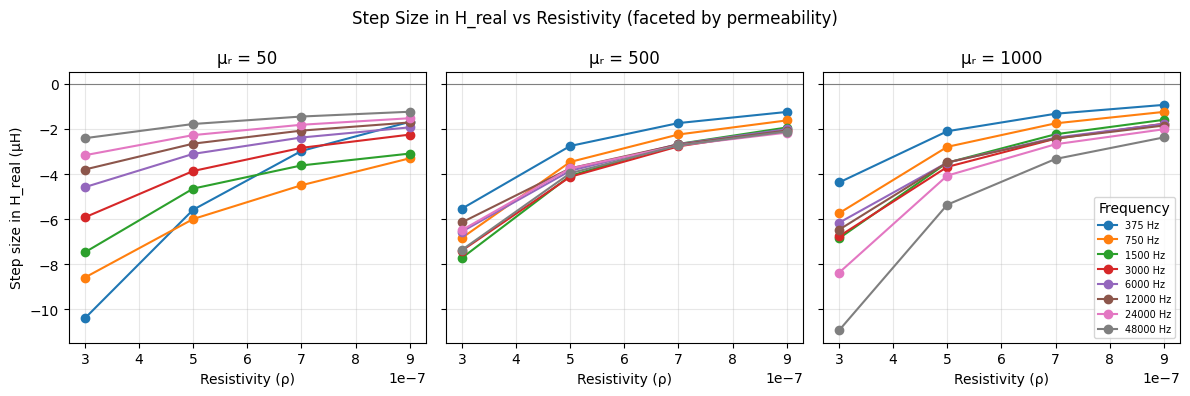

In [ ]:
# Response vs resistivity 
# step-to-step change as resistivity increases
real_cols = ['H_real_375','H_real_750','H_real_1500', 'H_real_3000', 'H_real_6000', 'H_real_12000', 'H_real_24000', 'H_real_48000']

for p in sorted(df['permeability'].unique()):
    r_sub_real = df[df['permeability'] == p].sort_values('resistivity').set_index('resistivity')
    # print(f'=== μᵣ = {p} (H_real, μH) ===')
    # display(round(r_sub_real[real_cols] *1e6, 3))
    print(f'--- Step Size (μᵣ = {p}) ---')
    display(round(r_sub_real[real_cols].diff() *1e6, 3))

plot_response_step_vs_resistivity(df, component='real')

--- Step Size (μᵣ = 50) ---


,H_imag_375,H_imag_750,H_imag_1500,H_imag_3000,H_imag_6000,H_imag_12000,H_imag_24000,H_imag_48000
resistivity,,,,,,,,
2.000000e-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4.000000e-07,-0.715,1.473,2.086,2.528,2.163,1.754,1.627,1.540
6.000000e-07,-2.541,0.290,1.144,1.305,1.207,1.024,1.014,1.036
8.000000e-07,-2.407,-0.656,0.809,0.843,0.794,0.694,0.725,0.780
1.000000e-06,-1.915,-1.112,0.480,0.655,0.561,0.508,0.555,0.624


--- Step Size (μᵣ = 100) ---


,H_imag_375,H_imag_750,H_imag_1500,H_imag_3000,H_imag_6000,H_imag_12000,H_imag_24000,H_imag_48000
resistivity,,,,,,,,
2.000000e-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4.000000e-07,-1.012,-0.007,1.335,2.143,2.005,1.712,1.697,1.631
6.000000e-07,-1.730,-0.243,0.399,0.967,0.997,0.897,0.992,1.106
8.000000e-07,-1.876,-0.472,0.173,0.537,0.594,0.555,0.664,0.812
1.000000e-06,-1.658,-0.709,0.093,0.331,0.387,0.371,0.478,0.630


--- Step Size (μᵣ = 200) ---


...

--- Step Size (μᵣ = 900) ---


,H_imag_375,H_imag_750,H_imag_1500,H_imag_3000,H_imag_6000,H_imag_12000,H_imag_24000,H_imag_48000
resistivity,,,,,,,,
2.000000e-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4.000000e-07,-2.233,-2.097,-1.176,-0.126,-0.214,-1.206,-1.803,0.050
6.000000e-07,-1.190,-1.229,-0.879,-0.330,-0.205,-0.510,-0.960,-0.891
8.000000e-07,-0.807,-0.833,-0.661,-0.335,-0.234,-0.355,-0.561,-0.678
1.000000e-06,-0.609,-0.617,-0.520,-0.302,-0.234,-0.303,-0.382,-0.485


--- Step Size (μᵣ = 1000) ---


,H_imag_375,H_imag_750,H_imag_1500,H_imag_3000,H_imag_6000,H_imag_12000,H_imag_24000,H_imag_48000
resistivity,,,,,,,,
2.000000e-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4.000000e-07,-2.225,-2.123,-1.237,-0.232,-0.413,-1.508,-2.121,0.093
6.000000e-07,-1.171,-1.231,-0.902,-0.365,-0.264,-0.638,-1.158,-1.063
8.000000e-07,-0.784,-0.831,-0.672,-0.353,-0.261,-0.414,-0.685,-0.822
1.000000e-06,-0.589,-0.612,-0.525,-0.315,-0.250,-0.335,-0.462,-0.597


(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'μᵣ = 50'}, xlabel='Resistivity (ρ)', ylabel='Step size in H_imag (μH)'>,
        <Axes: title={'center': 'μᵣ = 500'}, xlabel='Resistivity (ρ)'>,
        <Axes: title={'center': 'μᵣ = 1000'}, xlabel='Resistivity (ρ)'>],
       dtype=object))

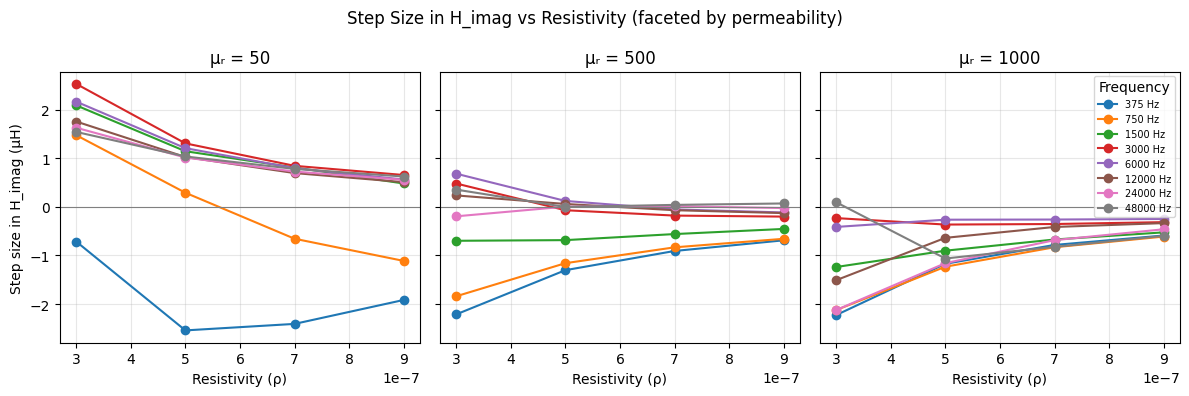

In [ ]:
imag_cols= [ 'H_imag_375','H_imag_750','H_imag_1500', 'H_imag_3000', 'H_imag_6000', 'H_imag_12000', 'H_imag_24000', 'H_imag_48000']

for p in sorted(df['permeability'].unique()):
    sub = df[df['permeability'] == p].sort_values('resistivity').set_index('resistivity')
    # print(f'=== μᵣ = {p} (H_imag, μH) ===')
    # display(round(sub[imag_cols] *1e6, 3))
    print(f'--- Step Size (μᵣ = {p}) ---')
    display(round(sub[imag_cols].diff() *1e6, 3))

plot_response_step_vs_resistivity(df, component='imag')